# A Hands-on Tutorial for Bayesian Neural Networks

(Part 1: regression)

[Yingzhen Li](http://yingzhenli.net/home/en/)

(As part of the BNN lecture at [ProbAI 2022](https://probabilistic.ai/))

In this tutorial, you will implement various Bayesian neural network methods based on variational inference.

We will go through regression tasks to see the applications of uncertainty estimation in practice, including a case study on Bayesian optimisation.

**How to use this tutorial notebook?**

*   Read the descriptions in the text;
*   Fill in the missing code whenever you see a block that looks like below:

```
### beginning of your code ###
[insert your own code here]
### end of your code ###
```
There will be hints provided in the code blocks as well to guide you through.

Let us set up the required packages, and then, enjoy 😊

In [ ]:
%matplotlib inline

import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist
from torch.utils.data import Dataset, DataLoader

EPS = 1e-5  # define a small constant for numerical stability control

# What is a Bayesian neural network?

In short, a Bayesian neural network (BNN) is a neural network that use (approximate) Bayesian inference for uncertainty estimation. For example, we can treat the NN parameters as random variables and infer them using (approximate) Bayesian posterior inference.

For the mathematical foundation, see [lecture notes here](http://yingzhenli.net/home/pdf/ProbAI2022_lecture_note.pdf).

# Implementing the BNN with mean-field variational inference (MFVI)

In this part, you will implement the Bayes-by-backprop algorithm by [Blundell et al. (2015)](https://arxiv.org/abs/1505.05424), which is doing mean-field variational inference (MFVI) in weight space for Bayesian neural networks.

For the mathematical foundation, see [lecture notes here](http://yingzhenli.net/home/pdf/ProbAI2022_lecture_note.pdf).


## Implementing the ```MFVILinear``` class and construct a BNN

We will implement the MFVI approach in a modular way, so we need a "BNN layer" module ```MFVILinear``` to start with. This will allow us to stack-up many network layers efficiently. Then we will implement the training & testing functions, and test the model's performance with a regression example.

In below block you will implment a BNN layer with mean-field variational inference (MFVI), and more specifically:

* the initialisation of the variational parameters
* the forward pass with Monte Carlo
* the $KL[q||p]$ regularisation term for one layer, i.e., $KL[q(W) || p(W)] + KL[q(b) || p(b)]$

In [ ]:
class MFVILinear(nn.Module):
    """Applies a linear transformation to the incoming data: y = xW^T + b, where 
    the weight W and bias b are sampled from the q distribution.
    """

    def __init__(self, dim_in, dim_out, prior_weight_std=1.0, prior_bias_std=1.0, init_std=0.05,
                 sqrt_width_scaling=False, device=None, dtype=None):
        factory_kwargs = {'device': device, 'dtype': dtype}
        super(MFVILinear, self).__init__()
        self.dim_in = dim_in  # dimension of network layer input
        self.dim_out = dim_out  # dimension of network layer output

        # define the trainable variational parameters for q distribtuion
        # first define and initialise the mean parameters

        """
        Any nn.Parameter will automatically be added to the model's list of trainable parameters
        This means these parameters will be updated during backpropagation when you call optimizer.step().
        
        Here, weight_mean and bias_mean are trainable parameters representing the mean of the variational
          posterior distribution for the weights and biases, respectively.
        """

        self.weight_mean = nn.Parameter(torch.empty((dim_out, dim_in), **factory_kwargs))
        self.bias_mean = nn.Parameter(torch.empty(dim_out, **factory_kwargs))
        self._weight_std_param = nn.Parameter(torch.empty((dim_out, dim_in), **factory_kwargs))
        self._bias_std_param = nn.Parameter(torch.empty(dim_out, **factory_kwargs))
        self.reset_parameters(init_std)

        # define the prior parameters (for prior p, assume the mean is 0)
        prior_mean = 0.0
        if sqrt_width_scaling:  # prior variance scales as 1/dim_in
            prior_weight_std /= self.dim_in ** 0.5

        """
        is used to register a tensor as part of a PyTorch module, but unlike nn.Parameter,
          these tensors are not trainable. They are typically used for values that should be 
          part of the model's state (e.g., constants, hyperparameters, or intermediate results) 
          but do not require gradients.
        
        """
        self.register_buffer('prior_weight_mean', torch.full_like(self.weight_mean, prior_mean))
        self.register_buffer('prior_weight_std', torch.full_like(self._weight_std_param, prior_weight_std))
        self.register_buffer('prior_bias_mean', torch.full_like(self.bias_mean, prior_mean))
        self.register_buffer('prior_bias_std', torch.full_like(self._bias_std_param, prior_bias_std)) 

        """
        
        Why Use nn.Parameter vs. register_buffer?
            nn.Parameter: Use for quantities that should be learned during training (e.g., weights, biases).
            register_buffer: Use for quantities that are fixed but need to be part
              of the model's state (e.g., prior parameters, normalization statistics).
        """

    def extra_repr(self):
        """
        The extra_repr method is a special method in PyTorch's nn.Module class 
            that allows you to customize the string representation of a module. 
            This is useful for debugging or logging, as it provides a concise summary of the module's key attributes.
        """
        s = "dim_in={}, dim_in={}, bias=True".format(self.dim_in, self.dim_out)
        weight_std = self.prior_weight_std.data.flatten()[0]
        if torch.allclose(weight_std, self.prior_weight_std):
            s += f", weight prior std={weight_std.item():.2f}"
        bias_std = self.prior_bias_std.flatten()[0]
        if torch.allclose(bias_std, self.prior_bias_std):
            s += f", bias prior std={bias_std.item():.2f}"
        return s
    
        """
        Why this check? We want the prior to be uniform (all values equal) unless there’s a specific reason 
        to do otherwise. The check ensures the prior is behaving as expected before summarizing it in the output.
        """
    

    def reset_parameters(self, init_std=0.05):

        nn.init.kaiming_uniform_(self.weight_mean, a=math.sqrt(5))
        bound = self.dim_in ** -0.5

        """This line modifies self.bias_mean in-place by filling it with values sampled uniformly from the range [-bound, bound]."""
        nn.init.uniform_(self.bias_mean, -bound, bound)
        _init_std_param = np.log(init_std) 

        "# q(W)=N(weight_mean,exp(_weight_std_param)^2) "
        self._weight_std_param.data = torch.full_like(self.weight_mean, _init_std_param) 
        "q(b)=N(bias_mean,exp(_bias_std_param)^2)"
        self._bias_std_param.data = torch.full_like(self.bias_mean, _init_std_param)

    # define the q distribution standard deviations with property decorator
    @property
    def weight_std(self):
        """
        Compute std=exp(_weight_std_param)

        Step 1:
        - 1. Exp Converts the log-standard-deviation (_weight_std_param) back to the standard deviation:
        - 2. Clamp --> Ensures the standard deviation never falls below a small positive value
        """
        return torch.clamp(torch.exp(self._weight_std_param), min=EPS)

    @property
    def bias_std(self):
        """Similarly as the previous one..."""
        return torch.clamp(torch.exp(self._bias_std_param), min=EPS)

    # KL divergence KL[q||p] between two Gaussians
    def kl_divergence(self):
        """
        
        Step 1: Define the distributions:
            Posterior (These are learned during training): 
                q_weight: Gaussian with mean self.weight_mean and std self.weight_std.
                q_bias: Gaussian with mean self.bias_mean and std self.bias_std.
            Prior (These are fixed):
                p_weight: Gaussian with mean self.prior_weight_mean and std self.prior_weight_std.
                p_bias: Gaussian with mean self.prior_bias_mean and std self.prior_bias_std.
        Step 2: Compute KL divergence between q and p (for both weights and bias):
        """

        q_weight = dist.Normal(self.weight_mean, self.weight_std)
        p_weight = dist.Normal(self.prior_weight_mean, self.prior_weight_std)
        kl = dist.kl_divergence(q_weight, p_weight).sum()
        q_bias = dist.Normal(self.bias_mean, self.bias_std)
        p_bias = dist.Normal(self.prior_bias_mean, self.prior_bias_std)
        kl += dist.kl_divergence(q_bias, p_bias).sum()
        return kl

    # forward pass with Monte Carlo (MC) sampling
    def forward(self, input):
        """
        Step 1: Sample weights and biases from their distributions:
        Step 2: Applys the Linear transformation output = input⋅weight T+bias 
        """
        weight = self._normal_sample(self.weight_mean, self.weight_std)
        bias = self._normal_sample(self.bias_mean, self.bias_std)
        return F.linear(input, weight, bias)


    def _normal_sample(self, mean, std):
        """
        Re-parameterization trick:
            - 1. Sample from a standard normal distribution: z ~ N(0, 1)
            - 2. Scale and shift by mean and std: x = mean + std * z
            - 3. This ensures that the gradient of x with respect to mean and std is well-defined.
        """
        epsilon = torch.randn_like(std)
        return mean + std * epsilon

# construct a BNN
def make_mfvi_bnn(layer_sizes, activation='LeakyReLU', **layer_kwargs):
    nonlinearity = getattr(nn, activation)() if isinstance(activation, str) else activation
    net = nn.Sequential()
    for i, (dim_in, dim_out) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        net.add_module(f'MFVILinear{i}', MFVILinear(dim_in, dim_out, **layer_kwargs))
        if i < len(layer_sizes) - 2:
            net.add_module(f'Nonlinarity{i}', nonlinearity)
    return net

We have just defined the ```MFVILinear``` class and ```make_mfvi_bnn``` for network construction.

In below we define the training procedure of a BNN, mainly by defining the training objective. This also involves helper functions that collects the KL regularizers accross layers as well as a prediction function.

In particular, as we work with regression data, we will use Gaussian likelihood, i.e., $p(y | x, \theta) = N(y; f_{\theta}(x), \sigma^2)$ where $f_{\theta}$ is the neural network and $\sigma^2$ is the output variance parameter that we will also optimise.

In [ ]:
# collect the kl divergence for all MFVILinear layers
def kl_divergence(bnn):
    kl = 0.0
    for module in bnn:
        if hasattr(module, 'kl_divergence'):
            kl = kl + module.kl_divergence()
    return kl


def train_step(net, opt, data_loss_func, dataloader, N_data, beta=1.0):
    """
    Goal: Train the BNN by:
    1. Computing predictions (y_pred).
    2. Evaluating the loss (negative log-likelihood + KL divergence).
    3. Updating the model's parameters via backpropagation.
    """
    # 1, # Loop over mini-batches
    for _, (x, y) in enumerate(dataloader):
        x = x.to(device); y = y.to(device)


        opt.zero_grad()  #Reset gradients

        "Forward pass, compute predictions"
        y_pred = net(x)

        "Compute loss"
        nll = data_loss_func(y, y_pred).mean() #negative log-likelihood (per sample)
        kl = kl_divergence(net) # KL divergence (sum over all layers)
        loss = N_data * nll + beta * kl  # Scale NLL by dataset size

        # ! Sometimes you don't want to apply the full KL penalty at the start of training, it can overpower the NLL and make learning unstable.

        "Backward pass"
        loss.backward()
        opt.step()
    return nll, kl

def gauss_loglik(y, y_pred, log_noise_var):
    """
    computes the log-likelihood of observed data y under a Gaussian (normal) distribution, 
    where the model's predictions y_pred are treated as the mean, and the noise variance is learned.


    gauss_loglik gives log likelihood under p(y|x,w) (one sample of weights).
    """
    l2_dist = (y - y_pred).pow(2).sum(-1)
    return -0.5 * (log_noise_var + math.log(2*math.pi) + l2_dist * torch.exp(-log_noise_var))

# define the prediction function with Monte Carlo sampling using K samples
def predict(bnn, x_test, K=1):
    y_pred = []
    for _ in range(K):
        y_pred.append(bnn(x_test))
    # shape (K, batch_size, y_dim) or (batch_size, y_dim) if K = 1
    return torch.stack(y_pred, dim=0).squeeze(0)


def rmse(y, y_pred):
    """RMSE"""
    if len(y_pred.shape) > 2: # using K > 1 MC samples
        y_pred = y_pred.mean(0)
    return (y - y_pred).pow(2).sum(-1).mean().sqrt()


def test_nll(y, y_pred, data_loss_func):
    """
    test_nll gives an approximation of logp(y|x,D) by averaging over sampled weights.
    
    The condition if len(nll) == 2 detects if multiple forward passes (MC samples) were used.

    """
    nll = data_loss_func(y, y_pred)  # with shape (batch_size) or (K, batch_size)
    if len(nll) == 2:  # using K > 1 MC samples, we need to average log-likelihoods across samples.
        nll = -torch.logsumexp(-nll, dim=0) + math.log(nll.shape[0]) 
    return nll.mean()

## Testing: a simple regression task
We will run a simple 1-D regression task to test the implemented BNN, in terms of its predictive performance and uncertainty estimation.

Let's get some synthetic data:



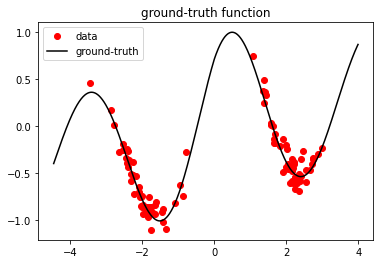

In [ ]:
def ground_truth_func(x):
    return np.sin(x * math.pi / 2 + 0.8) * np.exp(-0.1 * np.abs(x)) + 0.1 * x 

def gen_data(N_data, ground_truth_func, noise_std=None):
    # generate the training dataset, note here we will make data into 2 clusters
    x1 = np.random.randn(int(N_data/2), 1) * 0.5 + 2.0
    x2 = np.random.randn(int(N_data/2), 1) * 0.5 - 2.0
    x = np.concatenate([x1, x2], axis=0)
    y = ground_truth_func(x)
    if noise_std is not None and noise_std > EPS: 
        # assume homogeneous noise setting, i.e., "homoscedasticity"
        y += np.random.randn(y.shape[0], y.shape[1]) * noise_std
    return x, y

def normalise_data(x, mean, std):
    return (x - mean) / std

def unnormalise_data(x, mean, std):
    return x * std + mean

class regression_data(Dataset):
     def __init__(self, x, y, normalise=True):
         super(regression_data, self).__init__()
         self.update_data(x, y, normalise)
        
     def __len__(self):
         return self.x.shape[0]
        
     def __getitem__(self, index):
         x = torch.tensor(self.x[index]).float()
         y = torch.tensor(self.y[index]).float()
         return x, y

     def update_data(self, x, y, normalise=True, update_stats=True):
         assert x.shape[0] == y.shape[0]
         self.x = x
         self.y = y
         # normalise data
         self.normalise = normalise
         if update_stats:
             self.x_mean = self.x.mean(0) if normalise else 0.0
             self.x_std = self.x.std(0) if normalise else 1.0
             self.y_mean = self.y.mean(0) if normalise else 0.0
             self.y_std = self.y.std(0) if normalise else 1.0
         if self.normalise:
             self.x = normalise_data(self.x, self.x_mean, self.x_std)
             self.y = normalise_data(self.y, self.y_mean, self.y_std)
         
N_data = 100
noise_std = 0.1
x_train, y_train = gen_data(N_data, ground_truth_func, noise_std)
dataset = regression_data(x_train, y_train)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

# plot the training data and ground truth
x_test = np.arange(np.min(x_train) - 1.0, np.max(x_train)+1.0, 0.01)[:, np.newaxis]
y_test = ground_truth_func(x_test)
plt.plot(x_train, y_train, 'ro', label='data')
plt.plot(x_test, y_test, 'k-', label='ground-truth')
plt.legend()
plt.title('ground-truth function')
plt.show()

We set-up the hyper-parameters and build a BNN to be trained.



BNN architecture: 
 Sequential(
  (MFVILinear0): MFVILinear(dim_in=1, dim_in=50, bias=True, weight prior std=1.00, bias prior std=1.00)
  (Nonlinarity0): GELU()
  (MFVILinear1): MFVILinear(dim_in=50, dim_in=50, bias=True, weight prior std=1.00, bias prior std=1.00)
  (Nonlinarity1): GELU()
  (MFVILinear2): MFVILinear(dim_in=50, dim_in=1, bias=True, weight prior std=1.00, bias prior std=1.00)
)


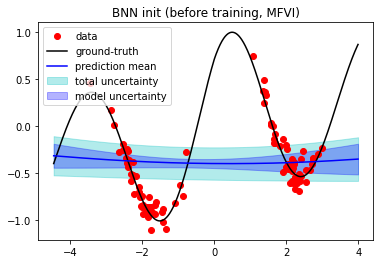

[0.0827434] 0.1 0.042364288208821585


In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
x_dim, y_dim = x_train.shape[1], y_train.shape[1]
# build a BNN, with hidden layer width = h_dim
h_dim = 50
layer_sizes = [x_dim, h_dim, h_dim, y_dim]
# you can change the activation function here or define your own customized activation
activation=nn.GELU() 
# you can change the prior parameters as you wish
layer_kwargs = {'prior_weight_std': 1.0,
                'prior_bias_std': 1.0,
                'sqrt_width_scaling': False,
                'init_std': 0.05,
                'device': device}
mfvi_regression_net = make_mfvi_bnn(layer_sizes, activation=activation, **layer_kwargs)
# we assume a Gaussian likelihood with homogeneuous noise
log_noise_var = nn.Parameter(torch.ones(size=(), device=device)*-3.0)
# print out the BNN settings
print("BNN architecture: \n", mfvi_regression_net)

# plot the BNN prior in function space
K = 50  # number of Monte Carlos samples used in test time
x_test_norm = normalise_data(x_test, dataset.x_mean, dataset.x_std)
x_test_norm = torch.tensor(x_test_norm, ).float().to(device)

def to_numpy(x):
    return x.detach().cpu().numpy() # convert a torch tensor to a numpy array

def get_regression_results(net, x, K, log_noise_var=None):
    y_pred = predict(net, x, K=K)  # shape (K, N_test, y_dim)
    y_pred_mean = y_pred.mean(0)
    if log_noise_var is not None:
        # note here the preditive std needs to count for output noise variance
        y_pred_std = (y_pred.var(0) + torch.exp(log_noise_var)).sqrt()
    else:
        y_pred_std = y_pred.std(0)
    # unnormalise
    y_pred_mean = unnormalise_data(to_numpy(y_pred_mean), dataset.y_mean, dataset.y_std)
    y_pred_std = unnormalise_data(to_numpy(y_pred_std), 0.0, dataset.y_std)
    return y_pred_mean, y_pred_std

# plot the BNN prior and ground truth
def plot_regression(x_train, y_train, x_test, y_pred_mean, y_pred_std_noiseless, y_pred_std, title=''):
    plt.plot(x_train, y_train, 'ro', label='data')
    plt.plot(x_test, y_test, 'k-', label='ground-truth')
    plt.plot(x_test, y_pred_mean, 'b-', label='prediction mean')
    # plot the uncertainty as +- 2 * std
    # first for the total uncertainty (model/epistemic + data/aleatoric)
    plt.fill_between(x_test[:,0], y_pred_mean[:,0]-2*y_pred_std[:,0], 
                     y_pred_mean[:,0]+2*y_pred_std[:,0], 
                     color='c', alpha=0.3, label='total uncertainty')
    # then for the model/epistemic uncertainty only
    plt.fill_between(x_test[:,0], y_pred_mean[:,0]-2*y_pred_std_noiseless[:,0], 
                     y_pred_mean[:,0]+2*y_pred_std_noiseless[:,0], 
                     color='b', alpha=0.3, label='model uncertainty')
    plt.legend()
    plt.title(title)
    plt.show()

y_pred_mean, y_pred_std_noiseless = get_regression_results(mfvi_regression_net, x_test_norm, K)
model_noise_std = unnormalise_data(to_numpy(torch.exp(0.5*log_noise_var)), 0.0, dataset.y_std)
y_pred_std = np.sqrt(y_pred_std_noiseless ** 2 + model_noise_std**2)
plot_regression(x_train, y_train, x_test, y_pred_mean, y_pred_std_noiseless, y_pred_std,
                title='BNN init (before training, MFVI)')
print(model_noise_std, noise_std, y_pred_std_noiseless.mean())

Now define the data loss (i.e., negative log-likelihood) and train the BNN.

Epoch 100, nll=6.995061874389648, kl=6524.4951171875
Epoch 200, nll=3.3041820526123047, kl=6280.9228515625
Epoch 300, nll=1.7511743307113647, kl=6049.814453125
Epoch 400, nll=1.5301305055618286, kl=5826.03369140625
Epoch 500, nll=1.5045077800750732, kl=5606.9345703125
Epoch 600, nll=1.0725151300430298, kl=5391.306640625
Epoch 700, nll=1.069087266921997, kl=5179.81103515625
Epoch 800, nll=1.5739126205444336, kl=4969.98583984375
Epoch 900, nll=1.0806735754013062, kl=4763.2314453125
Epoch 1000, nll=1.3580050468444824, kl=4557.697265625
Epoch 1100, nll=0.8312104940414429, kl=4354.61328125
Epoch 1200, nll=0.9971514940261841, kl=4155.3701171875
Epoch 1300, nll=0.4093616008758545, kl=3960.3203125
Epoch 1400, nll=0.9736379981040955, kl=3768.5576171875
Epoch 1500, nll=0.5539526343345642, kl=3578.880615234375
Epoch 1600, nll=0.44877609610557556, kl=3393.62109375
Epoch 1700, nll=0.3569214642047882, kl=3213.7373046875
Epoch 1800, nll=1.1329872608184814, kl=3039.186279296875
Epoch 1900, nll=0.87042

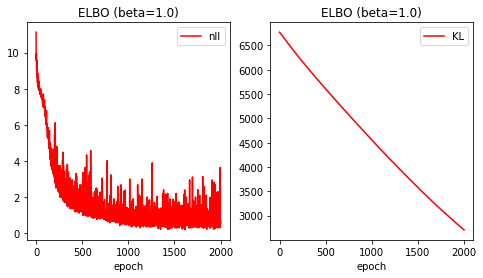

In [ ]:
# define the training function
def train_network(net, opt, dataloader, data_loss_func, learning_rate=1e-3, 
                  N_epochs=2000, beta=1.0, verbose=True):
    net.train()
    logs = []
    for i in range(N_epochs):

        #beta = i / (N_epochs - 1)  # ensure final epoch has beta = 1

        nll, kl = train_step(net, opt, data_loss_func, dataloader, 
                          N_data=len(dataloader.dataset), beta=beta)
        logs.append([to_numpy(nll), to_numpy(kl)])
        if (i+1) % 100 == 0 and verbose:
            print("Epoch {}, nll={}, kl={}".format(i+1, logs[-1][0], logs[-1][1]))
    return np.array(logs)

# start training
learning_rate = 1e-3
params = list(mfvi_regression_net.parameters()) + [log_noise_var]
opt = torch.optim.Adam(params, lr=learning_rate)
# define the regression loss: negative gaussian log-likelihood
data_loss_func = lambda y, y_pred: -gauss_loglik(y, y_pred, log_noise_var)
# hyper-parameters of training
beta = 1.0
N_epochs = 2000
# the training loop starts
logs = train_network(mfvi_regression_net, opt, dataloader, data_loss_func, 
                     beta=beta, verbose=True, N_epochs=N_epochs)

# plot the training curve
def plot_training_loss(logs, beta):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.plot(np.arange(logs.shape[0]), logs[:, 0], 'r-', label='nll')
    ax2.plot(np.arange(logs.shape[0]), logs[:, 1], 'r-', label='KL')
    ax1.legend()
    ax2.legend()
    ax1.set_xlabel('epoch')
    ax2.set_xlabel('epoch')
    ax1.set_title('ELBO (beta={})'.format(beta))
    ax2.set_title('ELBO (beta={})'.format(beta))
    plt.show()

plot_training_loss(logs, beta)

Training is now finished, let's plot the predictions again, but now it shows the mean & std of Bayesian predictive inference.

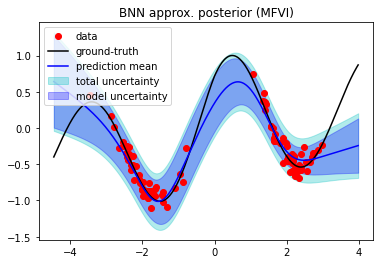

[0.12110004] 0.1 0.1665010710437822


In [ ]:
y_pred_mean, y_pred_std_noiseless = get_regression_results(mfvi_regression_net, x_test_norm, K)
model_noise_std = unnormalise_data(to_numpy(torch.exp(0.5*log_noise_var)), 0.0, dataset.y_std)
y_pred_std = np.sqrt(y_pred_std_noiseless ** 2 + model_noise_std**2)
plot_regression(x_train, y_train, x_test, y_pred_mean, y_pred_std_noiseless, y_pred_std,
                title='BNN approx. posterior (MFVI)')
print(model_noise_std, noise_std, y_pred_std_noiseless.mean())